# Salary Analysis & Prediction

##Objective
This project aims to analyze factors affecting salary and build a predictive model using machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
df=pd.read_csv('/content/job_salary_prediction_dataset.csv')
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## Data Understanding

In [4]:
df.shape
df.describe()
df.info()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


,0
job_title,12
experience_years,21
education_level,5
skills_count,19
industry,10
company_size,5
location,10
remote_work,3
certifications,6
salary,118956


The dataset contains 250,000 rows with no missing values

## Exploratory Data Analysis

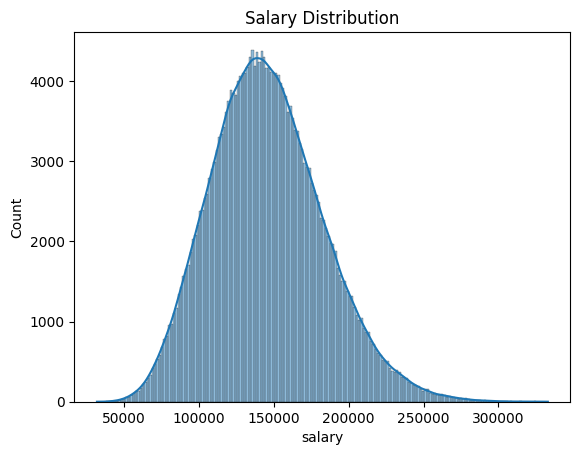

In [5]:
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')
plt.show()

Salary distribution is approximately normal with a slight positive skew, indicating most employees earn mid-range salaries, while a smaller portion earns significantly higher salaries.

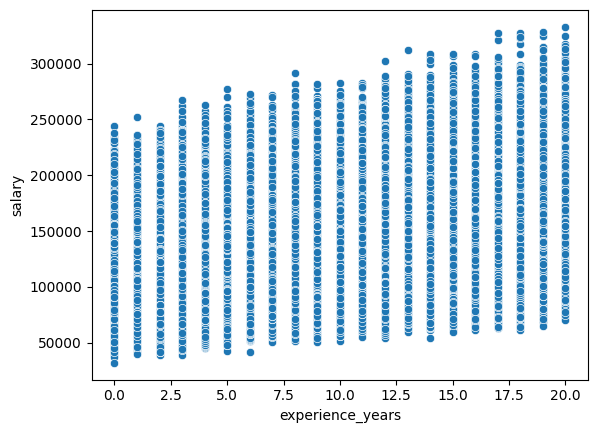

In [6]:
sns.scatterplot(x='experience_years', y='salary', data=df)
plt.show()

There is a positive relationship between experience and salary; however, the wide dispersion suggests other factors (education, industry, etc.) also significantly influence salary.

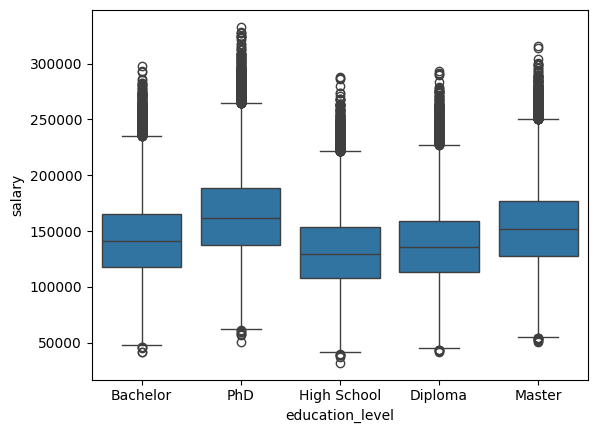

In [7]:
sns.boxplot(x='education_level', y='salary', data=df)
plt.show()

Higher education levels tend to correspond with higher salaries, with PhD holders earning the highest median salary. However, overlapping distributions indicate that education alone does not fully determine salary.

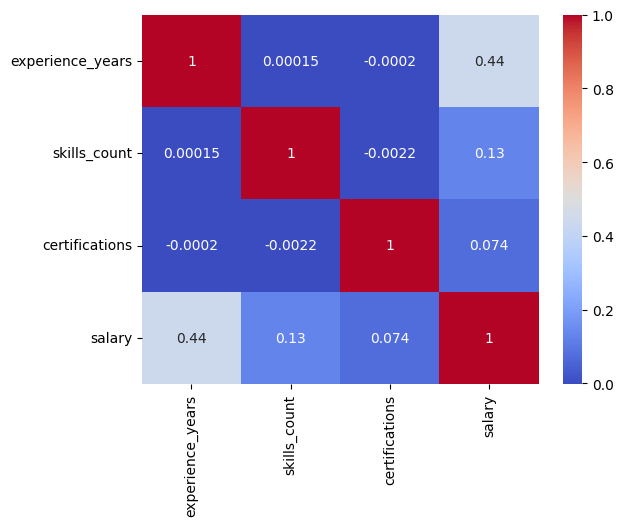

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Experience has the strongest correlation with salary among numerical features, while skills count and certifications show weak relationships.

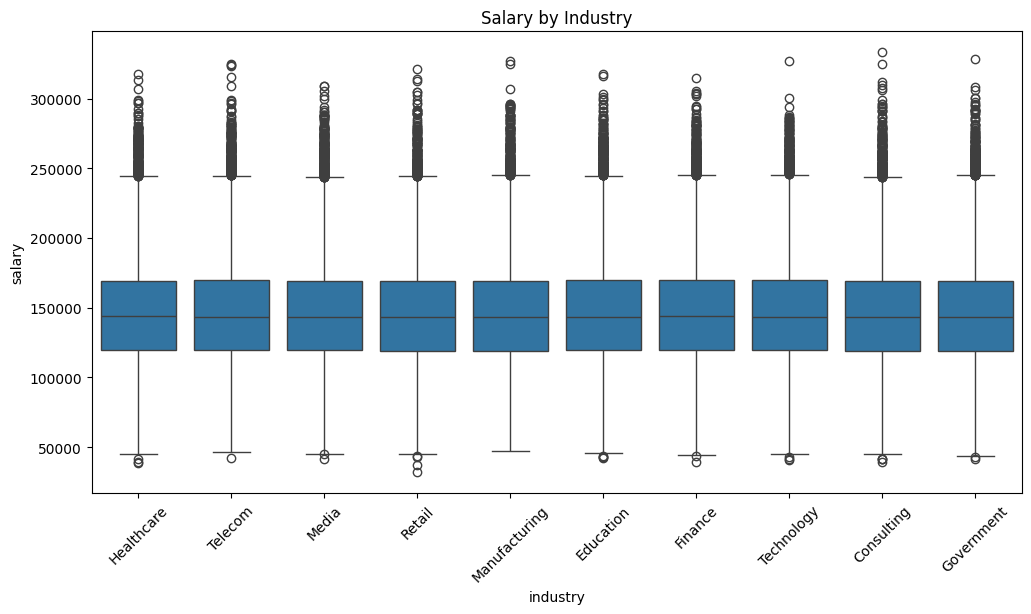

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(x='industry', y='salary', data=df)
plt.xticks(rotation=45)
plt.title('Salary by Industry')
plt.show()

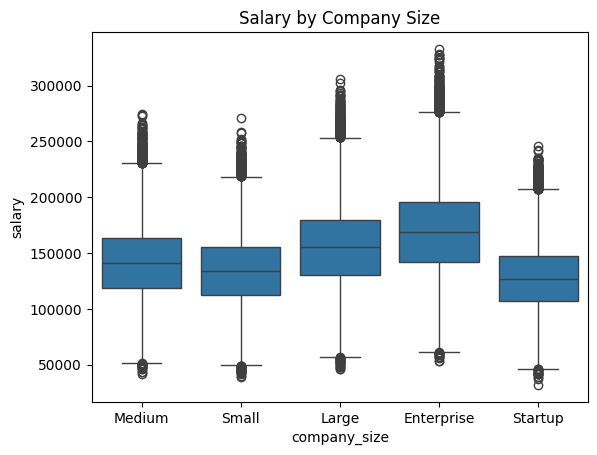

In [10]:
sns.boxplot(x='company_size', y='salary', data=df)
plt.title('Salary by Company Size')
plt.show()

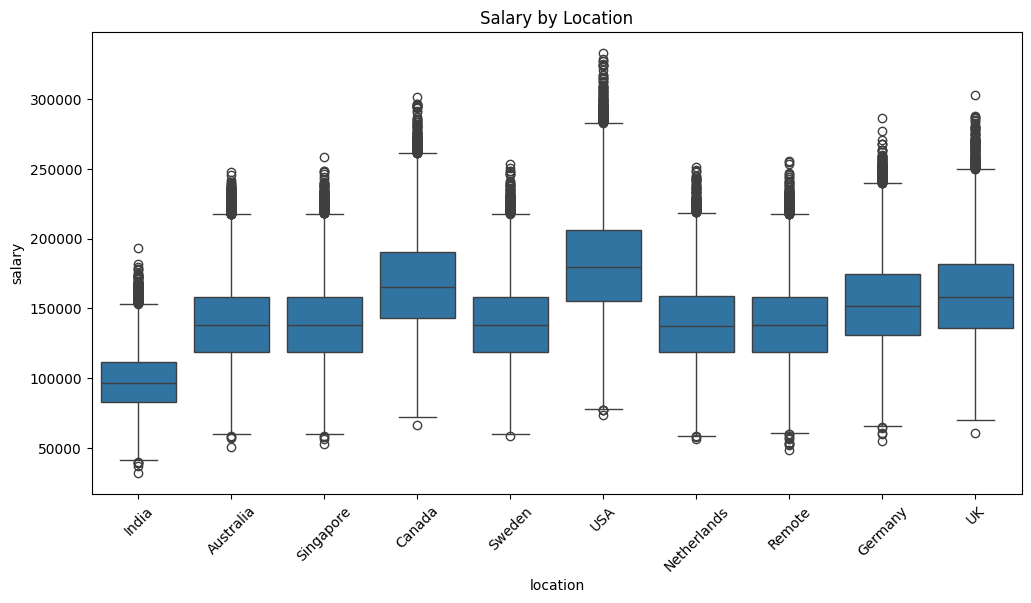

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(x='location', y='salary', data=df)
plt.xticks(rotation=45)
plt.title('Salary by Location')
plt.show()

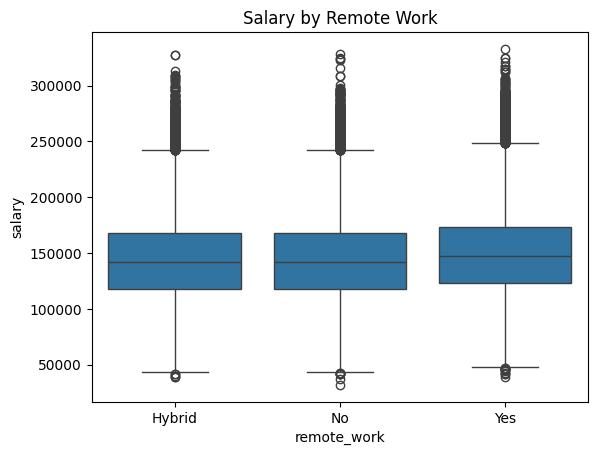

In [13]:
sns.boxplot(x='remote_work', y='salary', data=df)
plt.title('Salary by Remote Work')
plt.show()

In [14]:
df.groupby('industry')['salary'].mean().sort_values(ascending=False)

,salary
industry,
Education,145993.564547
Media,145891.271071
Telecom,145876.511967
Technology,145863.808377
Finance,145801.639468
Healthcare,145759.995702
Government,145613.869242
Manufacturing,145530.603301
Consulting,145451.638293


The Education and Media industries show the highest salaries in the dataset, indicating these sectors may offer compettitive compensation compared to others.

In [15]:
df.groupby('company_size')['salary'].mean().sort_values(ascending=False)

,salary
company_size,
Enterprise,169616.398957
Large,155711.112489
Medium,141537.535991
Small,134356.864298
Startup,127289.011974


Enterprise-level companies offer the highest salaries, suggesting that larger organizations have greater financiial capacity to provide competitive compensation. Smaller companies show more variability, indicating less standardized salary structures.

In [16]:
df.groupby('location')['salary'].mean().sort_values(ascending=False)

,salary
location,
USA,181716.303919
Canada,167391.273396
UK,160075.143018
Germany,153376.211000
Remote,139442.525155
Sweden,139440.637291
Australia,139362.150804
Singapore,139340.696625
Netherlands,139294.813644


The United States offers the hughest salary levels among all locations, highlighting the strong impact of geographic factors on compensation. This may reflect differences in cost of living, economic development, and industry concentration.

In [17]:
df.groupby('remote_work')['salary'].mean().sort_values(ascending=False)

,salary
remote_work,
Yes,149279.589822
Hybrid,143969.899839
No,143932.300941


Remote workers tend to have slightly higher salaries compared to non-remote roles, suggesting that remote opportunities may be associated with higher-paying poritions.

**Salary is influenced by multiple factors, with experience showing the strongest numerical correlation, while categorical factors such as industry, company size, and location play a significat role in differentiating salary levels. Enterprise companies in high-paying industries and developed regions (such as the US) tend to offer the highest compensation, with remote work also showing a slight positive association with salary.**

## Data Preprocessing

In [19]:
df_encoded=pd.get_dummies(df, drop_first=True)
df_encoded.head()

,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,109413,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,93764,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,148123,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,189123,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,165069,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


Categorical variebles are converted into numerical format using one-hot encoding.

In [21]:
x=df_encoded.drop('salary', axis=1)
y=df_encoded['salary']

## Modeling

In [22]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(
    x, y, test_size=0.2, random_state=42
)

## Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_train,y_train)

y_pred_lr=lr.predict(x_test)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae=mean_absolute_error(y_test,y_pred_lr)
rmse=np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2=r2_score(y_test,y_pred_lr)

print("Linear Regression:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Linear Regression:
MAE: 5436.0969367518055
RMSE: 7125.522904124896
R2: 0.963469022844696


## Random Forest

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train,y_train)

y_pred_rf=rf.predict(x_test)

In [35]:
mae_rf=mean_absolute_error(y_test,y_pred_rf)
rmse_rf=np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf=r2_score(y_test,y_pred_rf)

print("\nrandom Forest:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)


random Forest:
MAE: 5693.018592038335
RMSE: 7375.756852502002
R2: 0.9608581821826041


## Evaluation

The high R2 values (~0.96) indicate that the dataset has strong predictive structure, meaning salary can be explained well using the available features such as experience, location, and company characteristics. However, such high performance may also indicate that the dataset is relatively clean or synthetic, and may not fully capture real-world salary variability.

In [33]:
feature_importance=pd.Series(rf.feature_importances_, index=x.columns)
feature_importance.sort_values(ascending=False).head(10)

,0
experience_years,0.200342
location_India,0.181792
location_USA,0.075682
company_size_Startup,0.061108
education_level_PhD,0.060730
company_size_Small,0.050843
job_title_Data Analyst,0.044606
company_size_Medium,0.043669
job_title_Business Analyst,0.042465
location_Canada,0.034414


Experience is the most influential factor, confirming the moderate correlation observed during EDA. Location variables (such as USA and India) also play a major role, highlighting geographic salary disparities. Additionally, company size and higher education levels contribute significantly to salary differences.

## Conclusion

**This project analyzed salary prediction using a structured dataset with both numerical and categorical features. Exploratory data Analysis revealed that experience, industry, company size, and location significantly influence salary levels.**

**A linear Regression model achieved strong performance (R2~0.96), outperforming a more complex Random Forest model. This indicates that salary relationships in the dataset are largely linear.**

**Feature importance analysis confirmed that experience and location are the most critical drivers of salary, followed by company size and educational level.**

**While the model performs well, the high accuracy suggests the dataset may be relatively clean or synthetic, and future work could include more real-world variability for improved robustness.**